<a href="https://colab.research.google.com/github/antimleite/Agentes-Inteligentes/blob/main/Reconhecimento_de_Di%CC%81gitos_Manuscritos_(MNIST)_(1).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Reconhecimento de Dígitos Manuscritos com MNIST
### Visão Computacional — iCEV
### Prof. Romuere Silva

Trabalho final da disciplina. Escolhi o MNIST porque é um problema real e clássico de visão computacional.
A ideia é comparar o jeito tradicional (descritores + classificador) com CNN, igual vimos nas aulas.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.callbacks import EarlyStopping

print('tensorflow:', tf.__version__)

tensorflow: 2.20.0


## 1. Carregando os dados

O MNIST já vem dividido em treino e teste no próprio keras, facilita bastante

In [ ]:
(X_train, y_train), (X_test, y_test) = keras.datasets.mnist.load_data()

print('treino:', X_train.shape)
print('teste: ', X_test.shape)
print('classes:', np.unique(y_train))

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
treino: (60000, 28, 28)
teste:  (10000, 28, 28)
classes: [0 1 2 3 4 5 6 7 8 9]


In [ ]:
# vendo como sao os valores dos pixels
print('min:', X_train.min(), '| max:', X_train.max(), '| dtype:', X_train.dtype)

min: 0 | max: 255 | dtype: uint8


## 2. Explorando os dados

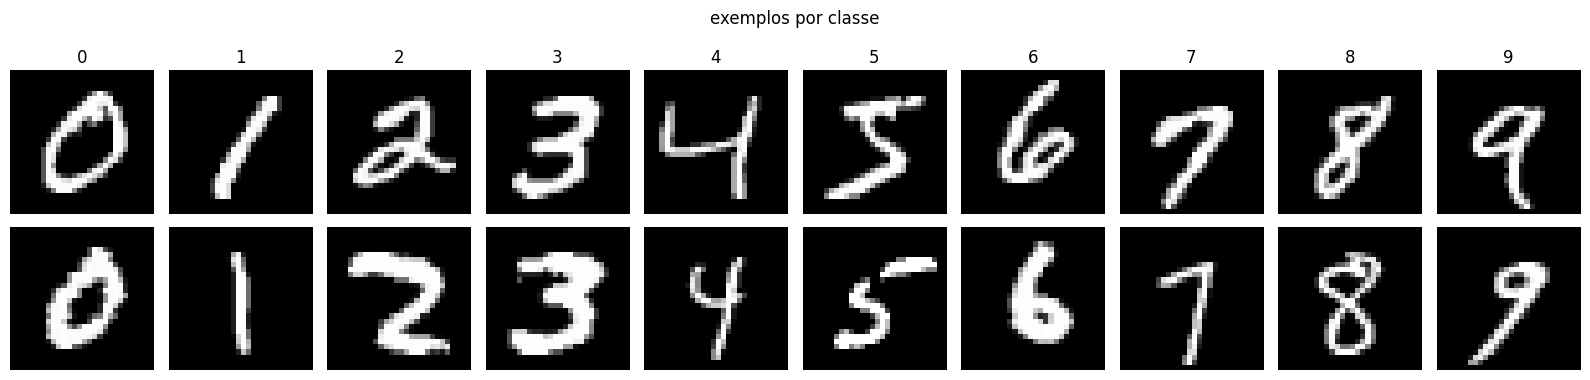

In [ ]:
# mostrando um exemplo de cada digito
fig, ax = plt.subplots(2, 10, figsize=(16, 4))

for d in range(10):
    idx = np.where(y_train == d)[0][0]
    ax[0, d].imshow(X_train[idx], cmap='gray')
    ax[0, d].set_title(str(d))
    ax[0, d].axis('off')

    # pegar outro exemplo do mesmo digito
    idx2 = np.where(y_train == d)[0][3]
    ax[1, d].imshow(X_train[idx2], cmap='gray')
    ax[1, d].axis('off')

plt.suptitle('exemplos por classe')
plt.tight_layout()
plt.show()

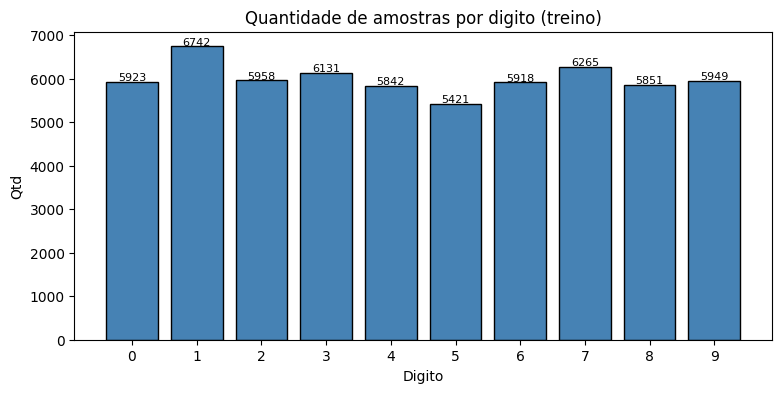

In [ ]:
# distribuicao das classes — verificar se ta balanceado
qtd = np.bincount(y_train)

plt.figure(figsize=(9,4))
plt.bar(range(10), qtd, color='steelblue', edgecolor='k')
plt.title('Quantidade de amostras por digito (treino)')
plt.xlabel('Digito')
plt.ylabel('Qtd')
plt.xticks(range(10))
for i, v in enumerate(qtd):
    plt.text(i, v + 30, str(v), ha='center', fontsize=8)
plt.show()

# ta bem balanceado, uns 6000 por classe

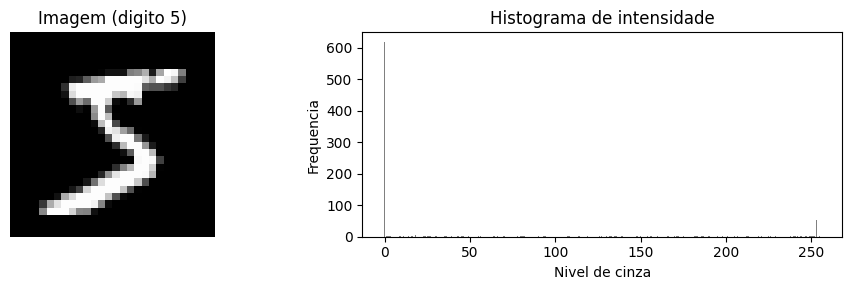

In [ ]:
# histograma de uma imagem — igual fizemos no notebook da unidade 1
from skimage.exposure import histogram

img_ex = X_train[0]
hist, bins = histogram(img_ex)

fig, ax = plt.subplots(1, 2, figsize=(10,3))
ax[0].imshow(img_ex, cmap='gray')
ax[0].set_title('Imagem (digito %d)' % y_train[0])
ax[0].axis('off')

ax[1].bar(bins, hist, color='gray')
ax[1].set_title('Histograma de intensidade')
ax[1].set_xlabel('Nivel de cinza')
ax[1].set_ylabel('Frequencia')
plt.tight_layout()
plt.show()

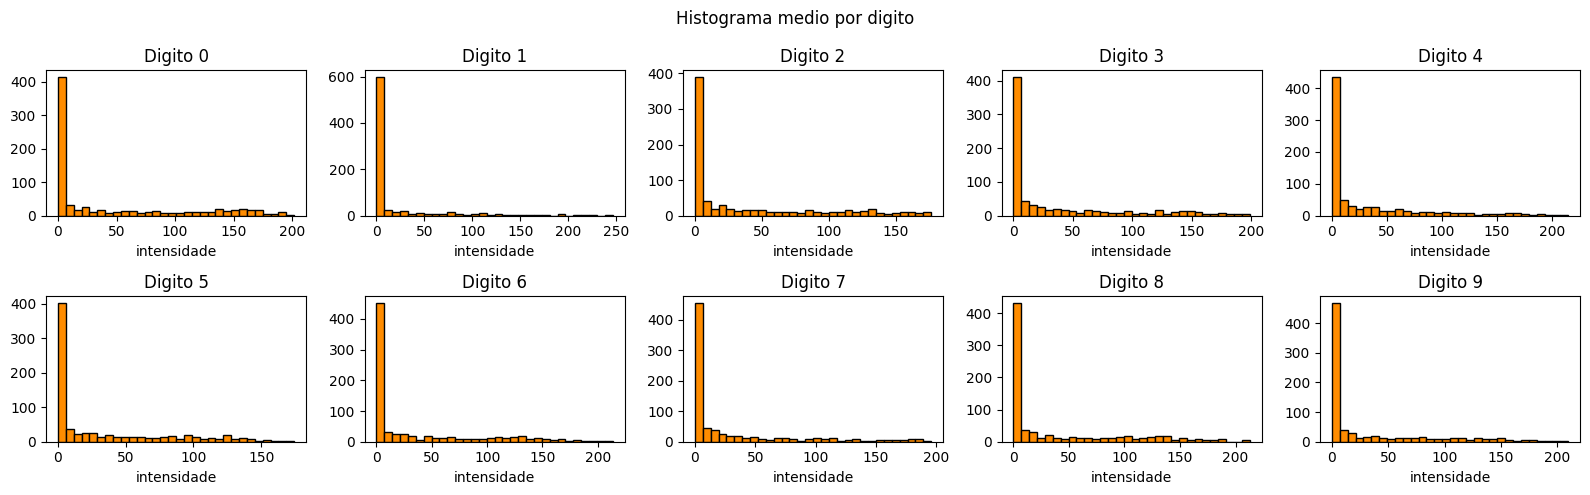

In [ ]:
# histograma medio por digito — ver se da pra diferenciar visualmente
fig, ax = plt.subplots(2, 5, figsize=(16, 5))
ax = ax.ravel()

for d in range(10):
    imgs = X_train[y_train == d]
    media = np.mean(imgs, axis=0).ravel()
    ax[d].hist(media, bins=30, color='darkorange', edgecolor='k')
    ax[d].set_title('Digito ' + str(d))
    ax[d].set_xlabel('intensidade')

plt.suptitle('Histograma medio por digito')
plt.tight_layout()
plt.show()

## 3. Pre-processamento

In [ ]:
# normalizando pra [0,1] — igual fizemos nos notebooks anteriores
# pro MLP vou achatar em vetor de 784 (28*28)

X_train_flat = X_train.reshape(len(X_train), -1) / 255.0
X_test_flat  = X_test.reshape(len(X_test), -1)   / 255.0

print('shape flat treino:', X_train_flat.shape)
print('shape flat teste :', X_test_flat.shape)

shape flat treino: (60000, 784)
shape flat teste : (10000, 784)


In [ ]:
# pra CNN precisa do canal — 28x28x1
X_train_cnn = (X_train.reshape(-1, 28, 28, 1)).astype('float32') / 255.0
X_test_cnn  = (X_test.reshape(-1, 28, 28, 1)).astype('float32')  / 255.0

# one hot encoding dos rotulos
y_train_ohe = keras.utils.to_categorical(y_train, 10)
y_test_ohe  = keras.utils.to_categorical(y_test,  10)

print('shape cnn treino :', X_train_cnn.shape)
print('shape ohe treino :', y_train_ohe.shape)
print('exemplo label ohe:', y_train_ohe[0], '-> digito', y_train[0])

shape cnn treino : (60000, 28, 28, 1)
shape ohe treino : (60000, 10)
exemplo label ohe: [0. 0. 0. 0. 0. 1. 0. 0. 0. 0.] -> digito 5


## 4. Abordagem Tradicional — MLP com pixels como atributos

Seguindo o que foi feito no notebook do histograma: usando os pixels diretamente como vetor de atributos e treinando um MLP (igual a funcao `classification` do notebook da unidade 1)

In [ ]:
# usando so 10k amostras pra nao demorar muito
# com todos os 60k melhora mas demora bastante no colab sem GPU
N = 10000

Xtr = X_train_flat[:N]
ytr = y_train[:N]

print('treinando MLP...')
clf = MLPClassifier(hidden_layer_sizes=(256, 128), activation='relu',
                    max_iter=30, random_state=42)
clf.fit(Xtr, ytr)

pred_mlp = clf.predict(X_test_flat)
acc_mlp  = accuracy_score(y_test, pred_mlp)

print('acuracia MLP: %.4f' % acc_mlp)

treinando MLP...
acuracia MLP: 0.9588


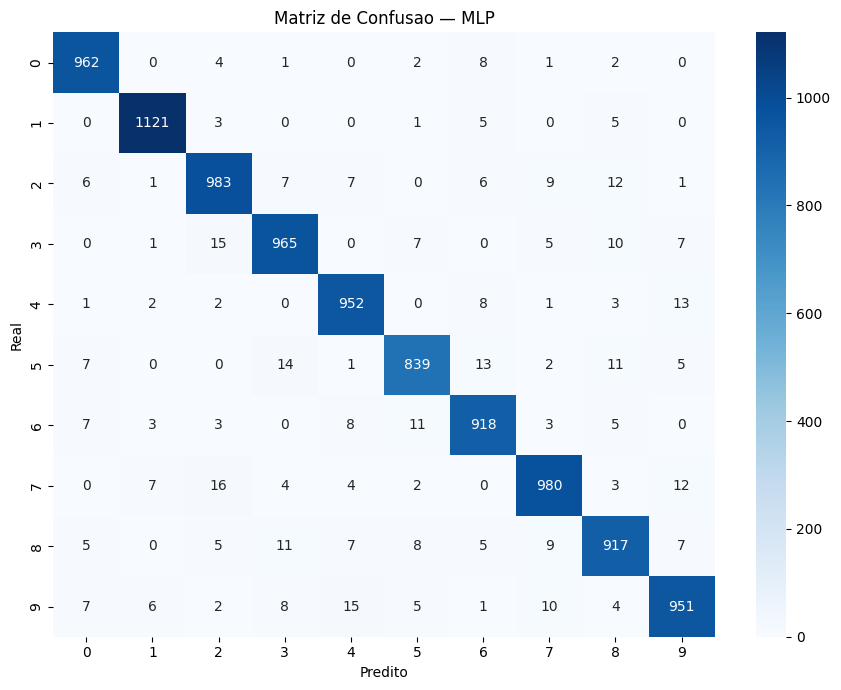

              precision    recall  f1-score   support

           0       0.97      0.98      0.97       980
           1       0.98      0.99      0.99      1135
           2       0.95      0.95      0.95      1032
           3       0.96      0.96      0.96      1010
           4       0.96      0.97      0.96       982
           5       0.96      0.94      0.95       892
           6       0.95      0.96      0.96       958
           7       0.96      0.95      0.96      1028
           8       0.94      0.94      0.94       974
           9       0.95      0.94      0.95      1009

    accuracy                           0.96     10000
   macro avg       0.96      0.96      0.96     10000
weighted avg       0.96      0.96      0.96     10000



In [ ]:
# matriz de confusao
cm_mlp = confusion_matrix(y_test, pred_mlp)

plt.figure(figsize=(9,7))
sns.heatmap(cm_mlp, annot=True, fmt='d', cmap='Blues',
            xticklabels=range(10), yticklabels=range(10))
plt.title('Matriz de Confusao — MLP')
plt.xlabel('Predito')
plt.ylabel('Real')
plt.tight_layout()
plt.show()

print(classification_report(y_test, pred_mlp))

## 5. Abordagem Deep Learning — CNN

Aqui vou implementar uma CNN parecida com o que o professor mostrou nas aulas (unidade 4),
adaptada pro MNIST que tem imagens 28x28 em escala de cinza.

In [ ]:
# montando a arquitetura
# 3 blocos conv+pool, dropout, e 2 camadas densas

model = Sequential()

# bloco 1
model.add(layers.Conv2D(32, (3,3), activation='relu', padding='same',
                        input_shape=(28,28,1), name='conv1'))
model.add(layers.MaxPooling2D((2,2), name='pool1'))

# bloco 2
model.add(layers.Conv2D(64, (3,3), activation='relu', padding='same', name='conv2'))
model.add(layers.MaxPooling2D((2,2), name='pool2'))

# mais uma conv — vi que ajuda bastante
model.add(layers.Conv2D(64, (3,3), activation='relu', padding='same', name='conv3'))

# camada totalmente conectada
model.add(layers.Flatten(name='flatten'))
model.add(layers.Dropout(0.5, name='dropout'))   # evitar overfitting
model.add(layers.Dense(128, activation='relu', name='fc1'))
model.add(layers.Dense(10,  activation='softmax', name='saida'))

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1 (Conv2D)                  │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool1 (MaxPooling2D)            │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2 (Conv2D)                  │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool2 (MaxPooling2D)            │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv3 (Conv2D)                  │ (None, 7, 7, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 3136)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 3136)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc1 (Dense)                     │ (None, 128)            │       401,536 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ saida (Dense)                   │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 458,570 (1.75 MB)

 Trainable params: 458,570 (1.75 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

# early stopping pra parar quando nao melhorar mais
es = EarlyStopping(monitor='val_loss', patience=5,
                   restore_best_weights=True, verbose=1)

In [ ]:
historico = model.fit(
    X_train_cnn, y_train_ohe,
    epochs=20,
    batch_size=128,
    validation_split=0.1,
    callbacks=[es],
    verbose=1
)

Epoch 1/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 82s 190ms/step - accuracy: 0.9308 - loss: 0.2241 - val_accuracy: 0.9842 - val_loss: 0.0501
Epoch 2/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 80s 189ms/step - accuracy: 0.9804 - loss: 0.0619 - val_accuracy: 0.9860 - val_loss: 0.0458
Epoch 3/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 78s 186ms/step - accuracy: 0.9851 - loss: 0.0461 - val_accuracy: 0.9897 - val_loss: 0.0328
Epoch 4/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 78s 184ms/step - accuracy: 0.9882 - loss: 0.0378 - val_accuracy: 0.9917 - val_loss: 0.0332
Epoch 5/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 82s 184ms/step - accuracy: 0.9900 - loss: 0.0301 - val_accuracy: 0.9923 - val_loss: 0.0279
Epoch 6/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 77s 183ms/step - accuracy: 0.9913 - loss: 0.0267 - val_accuracy: 0.9923 - val_loss: 0.0259
Epoch 7/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 77s 183ms/step - accuracy: 0.9928 - loss: 0.0222 - val_accuracy: 0.9915 - val_loss: 0.0336
Epoch 8/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 84s 188ms/step - accuracy: 0.9934 - loss: 0

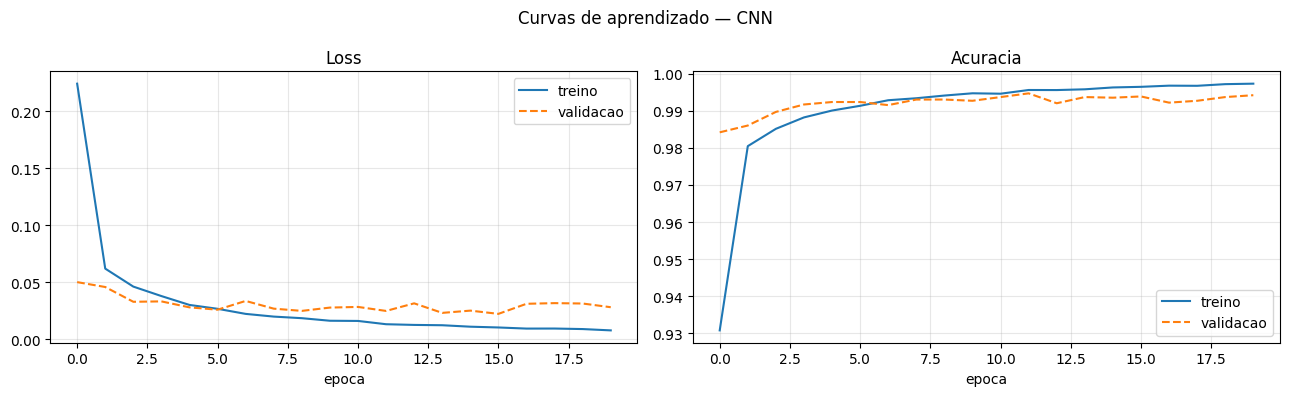

In [ ]:
# curvas de aprendizado
fig, ax = plt.subplots(1, 2, figsize=(13,4))

ax[0].plot(historico.history['loss'],     label='treino')
ax[0].plot(historico.history['val_loss'], label='validacao', linestyle='--')
ax[0].set_title('Loss')
ax[0].set_xlabel('epoca')
ax[0].legend()
ax[0].grid(alpha=0.3)

ax[1].plot(historico.history['accuracy'],     label='treino')
ax[1].plot(historico.history['val_accuracy'], label='validacao', linestyle='--')
ax[1].set_title('Acuracia')
ax[1].set_xlabel('epoca')
ax[1].legend()
ax[1].grid(alpha=0.3)

plt.suptitle('Curvas de aprendizado — CNN')
plt.tight_layout()
plt.show()

In [ ]:
# avaliando no teste
loss_cnn, acc_cnn = model.evaluate(X_test_cnn, y_test_ohe, verbose=0)
print('loss :', round(loss_cnn, 4))
print('acc  :', round(acc_cnn,  4))

probs    = model.predict(X_test_cnn)
pred_cnn = np.argmax(probs, axis=1)

loss : 0.02
acc  : 0.9942
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step


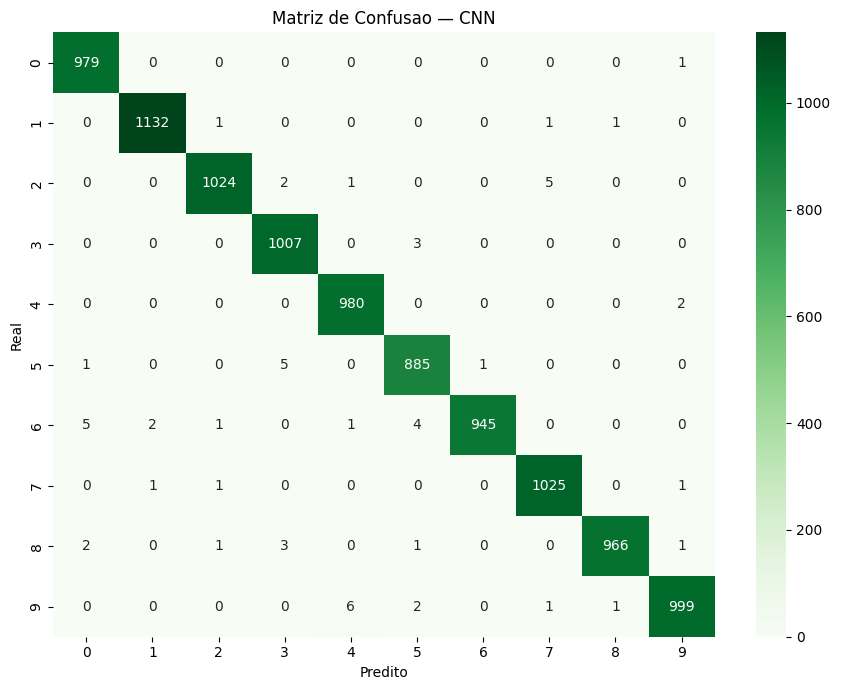

              precision    recall  f1-score   support

           0       0.99      1.00      1.00       980
           1       1.00      1.00      1.00      1135
           2       1.00      0.99      0.99      1032
           3       0.99      1.00      0.99      1010
           4       0.99      1.00      0.99       982
           5       0.99      0.99      0.99       892
           6       1.00      0.99      0.99       958
           7       0.99      1.00      1.00      1028
           8       1.00      0.99      0.99       974
           9       1.00      0.99      0.99      1009

    accuracy                           0.99     10000
   macro avg       0.99      0.99      0.99     10000
weighted avg       0.99      0.99      0.99     10000



In [ ]:
cm_cnn = confusion_matrix(y_test, pred_cnn)

plt.figure(figsize=(9,7))
sns.heatmap(cm_cnn, annot=True, fmt='d', cmap='Greens',
            xticklabels=range(10), yticklabels=range(10))
plt.title('Matriz de Confusao — CNN')
plt.xlabel('Predito')
plt.ylabel('Real')
plt.tight_layout()
plt.show()

print(classification_report(y_test, pred_cnn))

## 6. Analisando os erros

In [ ]:
erros = np.where(pred_cnn != y_test)[0]
print('total de erros:', len(erros), 'de', len(y_test))
print('taxa de erro: %.2f%%' % (len(erros)/len(y_test)*100))

total de erros: 58 de 10000
taxa de erro: 0.58%


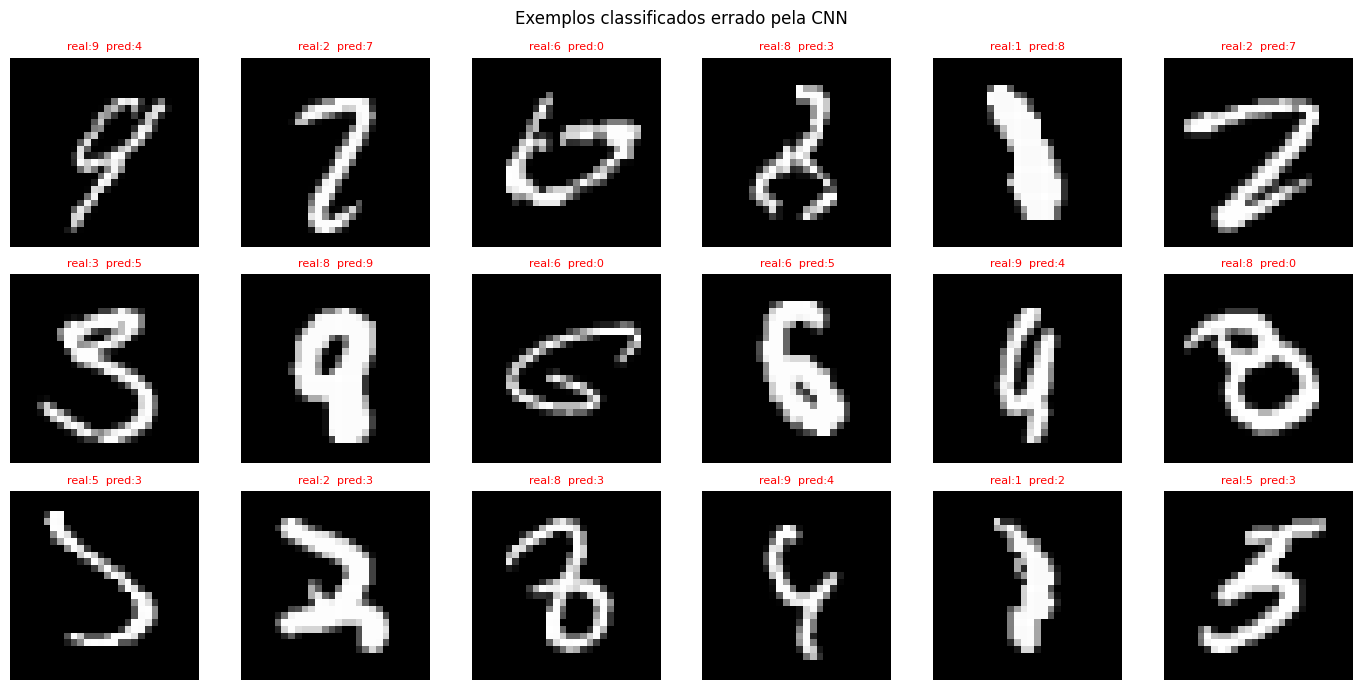

In [ ]:
# olhando alguns erros pra ver o que a CNN confundiu
fig, ax = plt.subplots(3, 6, figsize=(14, 7))
ax = ax.ravel()

for i in range(18):
    idx = erros[i]
    ax[i].imshow(X_test[idx], cmap='gray')
    ax[i].set_title('real:%d  pred:%d' % (y_test[idx], pred_cnn[idx]),
                    color='red', fontsize=8)
    ax[i].axis('off')

plt.suptitle('Exemplos classificados errado pela CNN')
plt.tight_layout()
plt.show()

# da pra ver que sao mesmo difíceis — até um humano erraria alguns

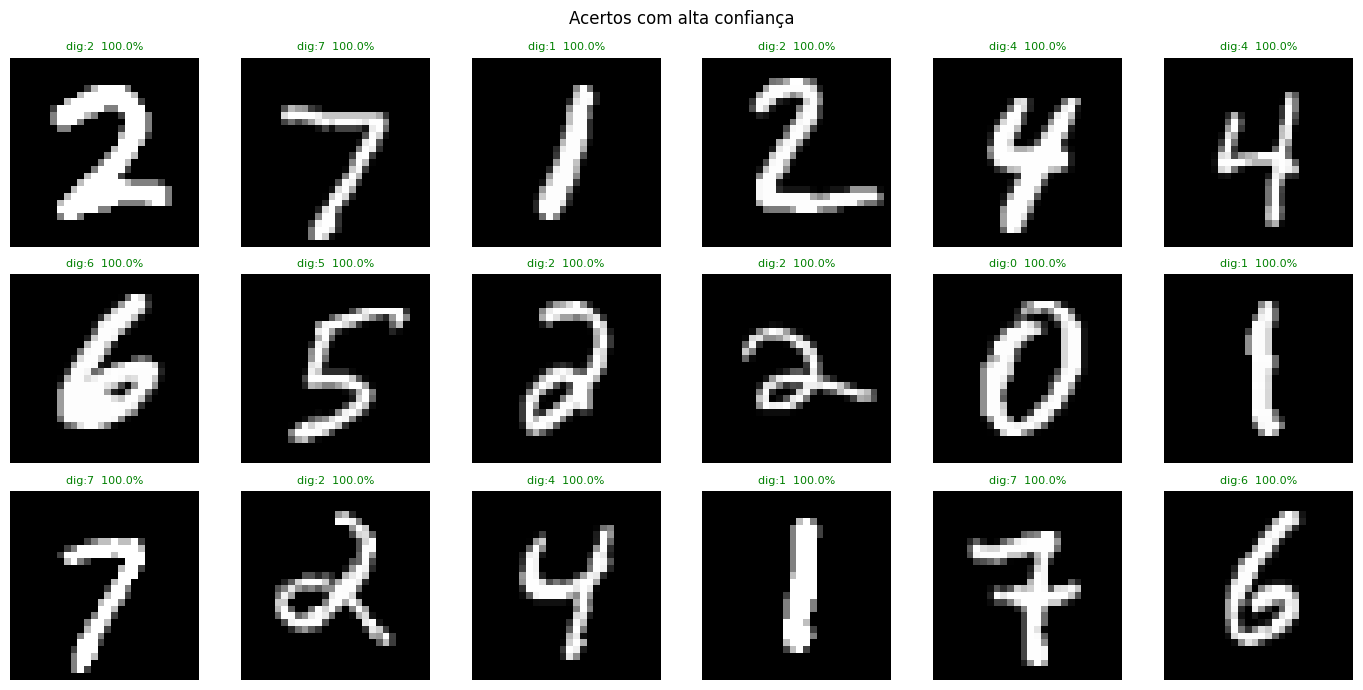

In [ ]:
# exemplos que a CNN acertou com muita confiança
acertos   = np.where(pred_cnn == y_test)[0]
conf      = probs[acertos].max(axis=1)
top_acert = acertos[np.argsort(conf)[-18:][::-1]]

fig, ax = plt.subplots(3, 6, figsize=(14, 7))
ax = ax.ravel()

for i in range(18):
    idx = top_acert[i]
    c   = probs[idx].max()
    ax[i].imshow(X_test[idx], cmap='gray')
    ax[i].set_title('dig:%d  %.1f%%' % (y_test[idx], c*100),
                    color='green', fontsize=8)
    ax[i].axis('off')

plt.suptitle('Acertos com alta confiança')
plt.tight_layout()
plt.show()

## 7. Visualizando o que a CNN aprendeu

shape dos filtros conv1: (3, 3, 1, 32)


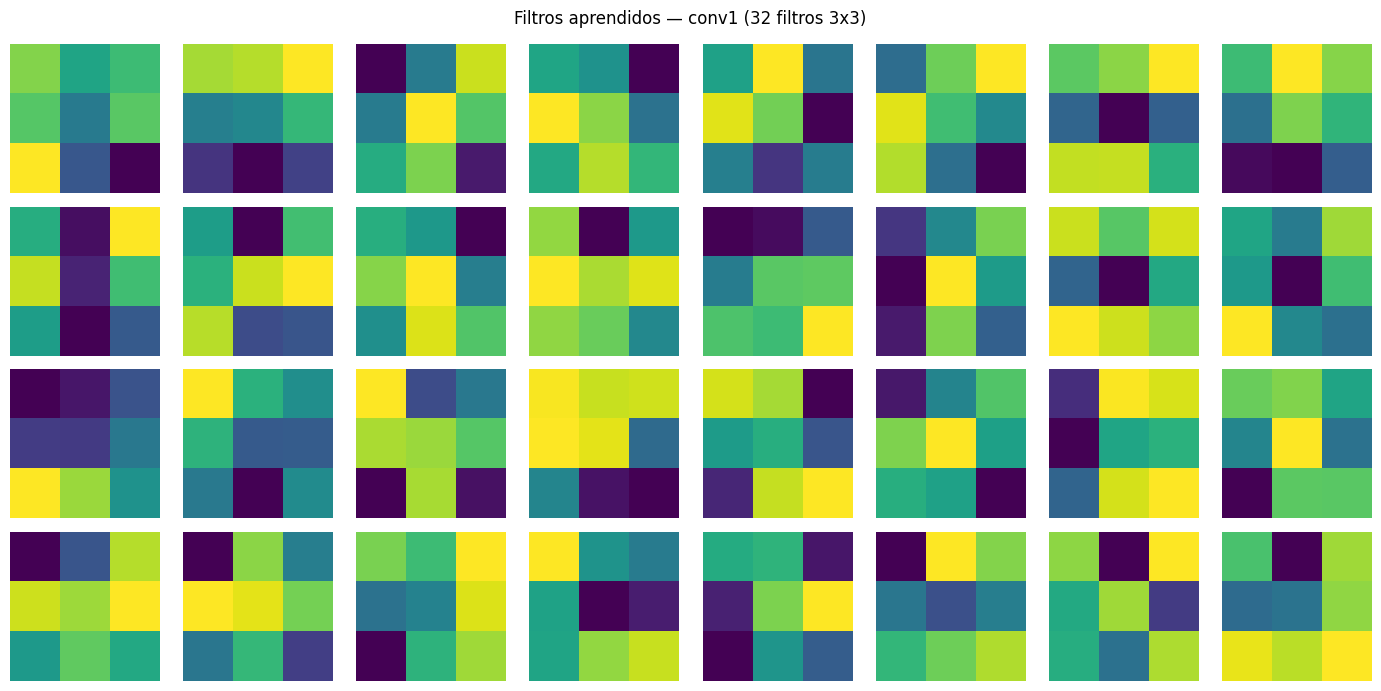

In [ ]:
# filtros da primeira camada convolucional
# cada filtro detecta um padrao diferente na imagem
filtros = model.get_layer('conv1').get_weights()[0]
print('shape dos filtros conv1:', filtros.shape)   # (3,3,1,32)

fig, ax = plt.subplots(4, 8, figsize=(14, 7))
ax = ax.ravel()

for i in range(32):
    ax[i].imshow(filtros[:,:,0,i], cmap='viridis')
    ax[i].axis('off')

plt.suptitle('Filtros aprendidos — conv1 (32 filtros 3x3)')
plt.tight_layout()
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
ativacoes shape: (1, 28, 28, 32)


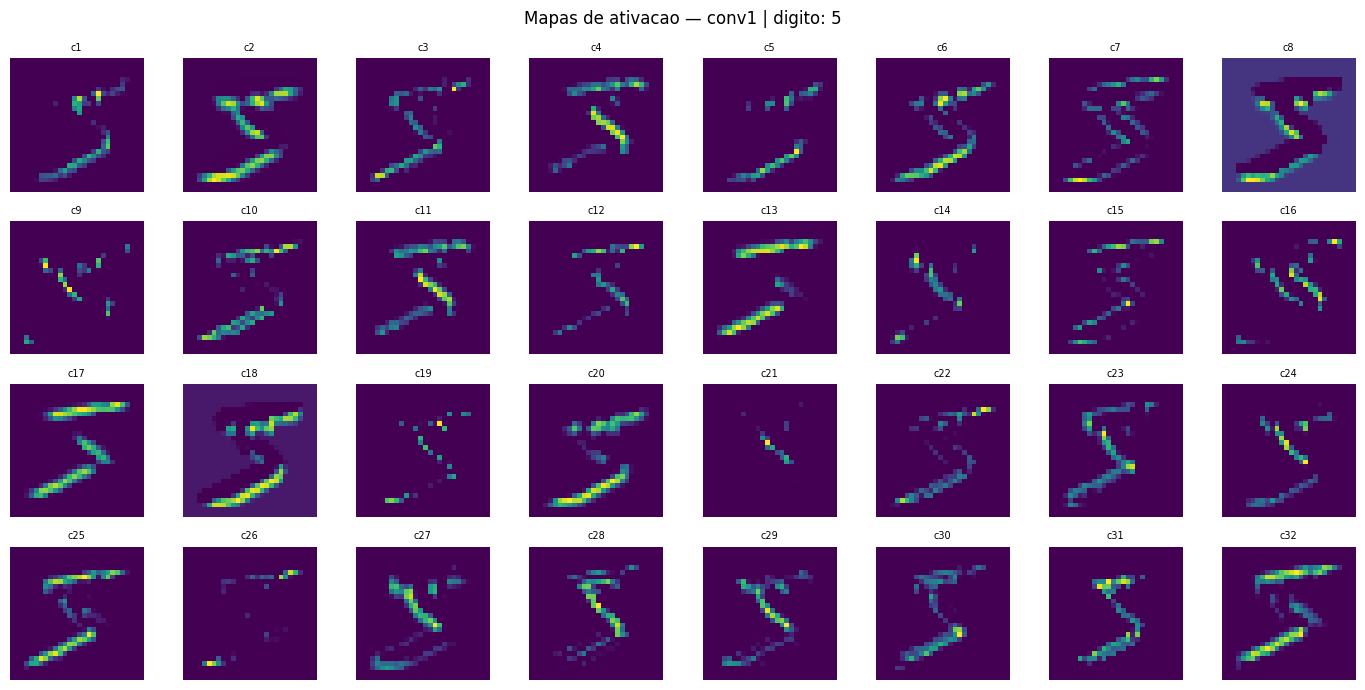

In [ ]:
# mapa de ativacao — o que a rede ve em cada canal depois da conv1
# model.input nao funciona direto em Sequential no keras 3
# solucao: recriar o modelo intermediario com functional API

inp = keras.Input(shape=(28, 28, 1))
out = model.get_layer('conv1')(inp)
modelo_intermed = Model(inp, out)

img_teste = X_train_cnn[0:1]   # primeiro exemplo
ativacoes = modelo_intermed.predict(img_teste)
print('ativacoes shape:', ativacoes.shape)  # (1, 28, 28, 32)

fig, ax = plt.subplots(4, 8, figsize=(14, 7))
ax = ax.ravel()

for i in range(32):
    ax[i].imshow(ativacoes[0,:,:,i], cmap='viridis')
    ax[i].set_title('c%d' % (i+1), fontsize=7)
    ax[i].axis('off')

plt.suptitle('Mapas de ativacao — conv1 | digito: %d' % y_train[0])
plt.tight_layout()
plt.show()

## 8. Testando com uma imagem aleatória do conjunto de teste

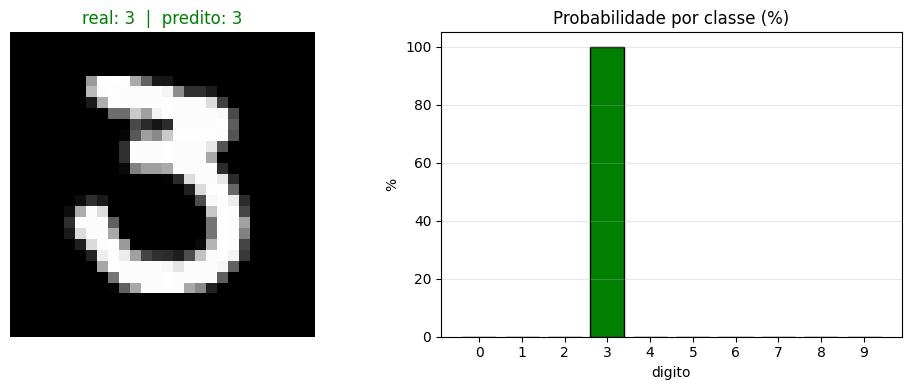

confianca: 100.00%


In [ ]:
# pega um exemplo aleatorio e mostra a predicao
idx  = np.random.randint(0, len(X_test))
img  = X_test_cnn[idx:idx+1]
prob = model.predict(img, verbose=0)[0]
pred = np.argmax(prob)
real = y_test[idx]

fig, ax = plt.subplots(1, 2, figsize=(10, 4))

ax[0].imshow(X_test[idx], cmap='gray')
titulo = 'real: %d  |  predito: %d' % (real, pred)
cor    = 'green' if real == pred else 'red'
ax[0].set_title(titulo, color=cor)
ax[0].axis('off')

cores_bar = ['green' if i == pred else 'steelblue' for i in range(10)]
ax[1].bar(range(10), prob*100, color=cores_bar, edgecolor='k')
ax[1].set_title('Probabilidade por classe (%)')
ax[1].set_xlabel('digito')
ax[1].set_ylabel('%')
ax[1].set_xticks(range(10))
ax[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

print('confianca: %.2f%%' % (prob[pred]*100))

## 9. Comparação final

In [ ]:
print('\n===== RESULTADOS =====')
print('MLP (pixels, %dk amostras treino): %.2f%%' % (N//1000, acc_mlp*100))
print('CNN (deep learning, 60k amostras): %.2f%%' % (acc_cnn*100))
print('Diferenca: +%.2f pp' % ((acc_cnn - acc_mlp)*100))
print('=====================')


===== RESULTADOS =====
MLP (pixels, 10k amostras treino): 95.88%
CNN (deep learning, 60k amostras): 99.42%
Diferenca: +3.54 pp


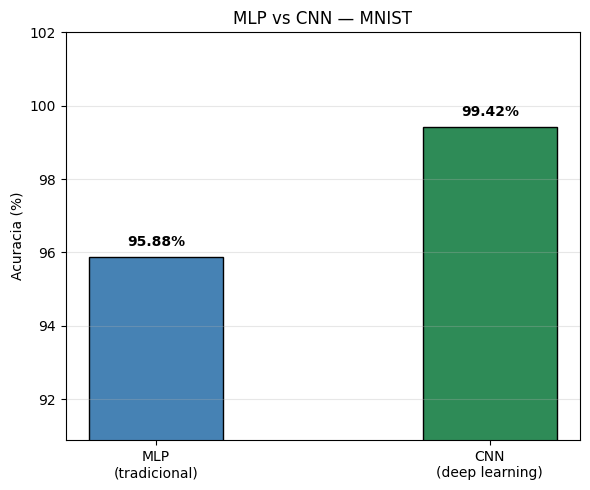

In [ ]:
plt.figure(figsize=(6,5))
plt.bar(['MLP\n(tradicional)', 'CNN\n(deep learning)'],
        [acc_mlp*100, acc_cnn*100],
        color=['steelblue', 'seagreen'], edgecolor='k', width=0.4)
plt.ylabel('Acuracia (%)')
plt.title('MLP vs CNN — MNIST')
plt.ylim([min(acc_mlp, acc_cnn)*100 - 5, 102])
plt.text(0, acc_mlp*100 + 0.3, '%.2f%%' % (acc_mlp*100), ha='center', fontweight='bold')
plt.text(1, acc_cnn*100  + 0.3, '%.2f%%' % (acc_cnn*100),  ha='center', fontweight='bold')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
# salvando o modelo
model.save('modelo_mnist.h5')
print('modelo salvo!')

# pra carregar depois:
# from tensorflow.keras.models import load_model
# model = load_model('modelo_mnist.h5')

modelo salvo!
